In [10]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.read_csv('group_20_1.csv')


In [11]:
X = df.drop(columns=['ID', 'Amyl', 'Country_raw', 'Ethnicity_raw'])
y = df['Amyl']
print(X.columns.tolist())
print(len(df))
print(y.value_counts().sort_index())
print((y.value_counts().sort_index() / len(y)).round(3))

['Age', 'Gender', 'Education', 'Country', 'Ethnicity', 'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']
1885
Amyl
0    1305
1     210
2     370
Name: count, dtype: int64
Amyl
0    0.692
1    0.111
2    0.196
Name: count, dtype: float64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=323, stratify=y
)

print(f"{X_train.shape}")
print(f"{X_test.shape}")
print(f"{y_train.value_counts().sort_index()}")

(1508, 12)
(377, 12)
Amyl
0    1044
1     168
2     296
Name: count, dtype: int64


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=323)

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=323),
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters", rf_grid.best_params_)
print(f"Best Macro F1: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
Best Macro F1: 0.5307


              precision    recall  f1-score   support

  Never Used       0.82      0.77      0.80       261
  Decade Ago       0.29      0.40      0.34        42
      Recent       0.51      0.50      0.50        74

    accuracy                           0.68       377
   macro avg       0.54      0.56      0.55       377
weighted avg       0.70      0.68      0.69       377

Test Macro F1: 0.5467


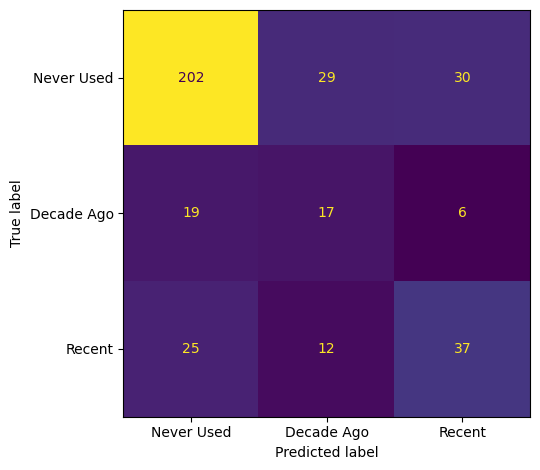

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

y_pred_rf = rf_grid.predict(X_test)

print(classification_report(y_test, y_pred_rf, 
      target_names=['Never Used', 'Decade Ago', 'Recent']))

macro_f1 = f1_score(y_test, y_pred_rf, average='macro')
print(f"Test Macro F1: {macro_f1:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=323),
    dt_param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print(f"Best Macro F1 Macro F1: {dt_grid.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10}
Best Macro F1 Macro F1: 0.4630


              precision    recall  f1-score   support

  Never Used       0.79      0.44      0.57       261
  Decade Ago       0.23      0.67      0.34        42
      Recent       0.36      0.51      0.42        74

    accuracy                           0.48       377
   macro avg       0.46      0.54      0.44       377
weighted avg       0.64      0.48      0.51       377

Test Macro F1: 0.4424


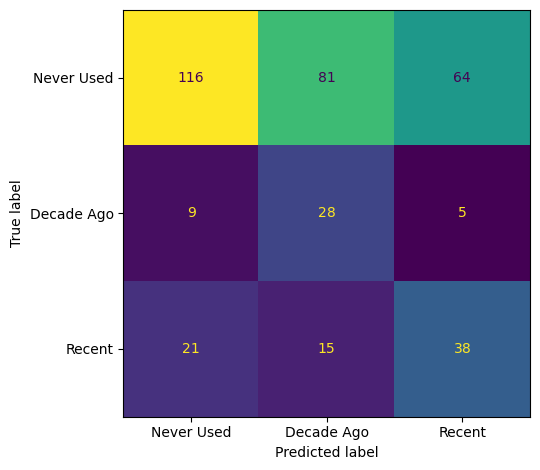

In [16]:
y_pred_dt = dt_grid.predict(X_test)

print(classification_report(y_test, y_pred_dt,
      target_names=['Never Used', 'Decade Ago', 'Recent']))

dt_macro_f1 = f1_score(y_test, y_pred_dt, average='macro')
print(f"Test Macro F1: {dt_macro_f1:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['Never Used', 'Decade Ago', 'Recent'],
    colorbar=False
)
plt.tight_layout()
plt.show()